In [13]:
#Importamos las librerias necesarias
# import IPython
import IPython.display
import tensorflow as tf #manejo de tensores y redes neuronales
import datetime as dt #fechas y deltas de tiempo 
import pandas as pd #menajo de dataframes
import numpy as np #manejo de de arrays de conjuntos de datos
#import yfinance as yf #descarga de series financieras
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\alfre\Downloads\aa.csv')

In [14]:

#Establecemos los tickers y los dias de nuestros analisis 
stocks = ['AA'] #Definimos la lista de acciones que estudiaremos 
days= 180 #Numero de días de información que descargaremos 

end_date = dt.datetime.now() #Se establece la fecha de hoy con la de inicio
start_date = end_date - dt.timedelta(days=days) #Se calcula la diferencia de tiempo

#Descargamos las series de tiempo con las que trabajaremos 
#stockdata= yf.download(stocks, start_date, end_date) #Definimos las fechas de inicio y fin
stockdata = df #Tomamos unicamente los valores de cierre para hacer predicciones

In [15]:
#Realizamos el plit de datos
#Definimos una variable con la longitud de nuestra serie
n = len(stockdata) 
#Tomamos el 70% de nuestros datos para generar un set de entrenamiento
train_df = stockdata[:int(n*0.7)] 
#Tomamos el 20% de nuestros datos para generar un set de validación
val_df = stockdata[int(n*0.7):int(n*0.9)]
#Tomamos el 10% restante de nuestros datos para generar un set de testeo
test_df = stockdata[int(n*0.9):]

In [16]:
#Estandarizacion
#calculamos la media  y desviación de nuestro sets de entrenamiento
train_mean = train_df.mean()
train_std = train_df.std()
#Estandarizamos los datos para evitar perdida de informacion
train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

In [17]:
#Creamos una clase para manejar las ventanas temporales de nuestra serie 
#WindowGenerator prepara los datos, establece el numero de pasos que
#se usaran para entrada y para salida del modelo  
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None):
      # Se almacena la informacion en bruto.
      self.train_df = train_df
      self.val_df = val_df
      self.test_df = test_df
    
      # Establecer los indices de las columnas.
      self.label_columns = label_columns
      if label_columns is not None:
        self.label_columns_indices = {name: i for i, name in
                                      enumerate(label_columns)}
      self.column_indices = {name: i for i, name in
                             enumerate(train_df.columns)}
    
      # Determinar los parametros de las ventanas.
      self.input_width = input_width
      self.label_width = label_width
      self.shift = shift  
    
      self.total_window_size = input_width + shift
     
      self.input_slice = slice(0, input_width)
      self.input_indices = np.arange(self.total_window_size)[self.input_slice]  
      
      self.label_start = self.total_window_size - self.label_width
      self.labels_slice = slice(self.label_start, None)
      self.label_indices = np.arange(self.total_window_size)[self.labels_slice] 
    
    #Devuelve un resumen del tamaño de la ventana y los indices de los inputs y las predicciones
    def __repr__(self):
      return '\n'.join([
          f'Total window size: {self.total_window_size}',
          f'Input indices: {self.input_indices}',
          f'Label indices: {self.label_indices}',
          f'Label column name(s): {self.label_columns}']) 
    
    #Divide la ventada de datos en bruto y divide en inputs y etiquetas(predicciones)
    def split_window(self, features):
      inputs = features[:, self.input_slice, :]
      labels = features[:, self.labels_slice, :]
      if self.label_columns is not None:
        labels = tf.stack(
            [labels[:, :, self.column_indices[name]] for name in self.label_columns],
            axis=-1)      
        
      # El corte (slicing) no conserva la forma estática del tensor, así que se establece manualmente.
      # Esto hace que los objetos `tf.data.Dataset` sean más fáciles de inspeccionar y depurar.      inputs.set_shape([None, self.input_width, None])
      labels.set_shape([None, self.label_width, None])    
        
      return inputs, labels 
  
    #Convierte el dataframe en un dataset de tensor flow, extrae las subseries
    #las covierte en lotes y las divide en entradas y salidas
    def make_dataset(self, data):
      data = np.array(data, dtype=np.float32)
      ds = tf.keras.utils.timeseries_dataset_from_array(
          data=data,
          targets=None,
          sequence_length=self.total_window_size,
          sequence_stride=1,
          shuffle=True,
          batch_size=8,)   
    
      ds = ds.map(self.split_window) 
    
      return ds 
    
    # Propiedad para obtener el dataset de entrenamiento
    @property
    def train(self):
      return self.make_dataset(self.train_df) 
    
    # Propiedad para obtener el dataset de validación
    @property
    def val(self):
      return self.make_dataset(self.val_df)   
    
    # Propiedad para obtener el dataset de prueba
    @property
    def test(self):
      return self.make_dataset(self.test_df)  
    
    # Propiedad para obtener (y guardar en caché) un lote de ejemplo    
    @property
    def example(self):
      """Get and cache an example batch of `inputs, labels` for plotting."""
      result = getattr(self, '_example', None)
      if result is None:
        # No example batch was found, so get one from the `.train` dataset
        result = next(iter(self.train))   # Toma el primer lote del conjunto de entrenamiento
        self._example = result            # Lo guarda para uso posterior
      return result
  
    def plot(self, model=None, plot_col='AA', max_subplots=3):
      inputs, labels = self.example
      plt.figure(figsize=(12, 8))
      plot_col_index = self.column_indices[plot_col]
      max_n = min(max_subplots, len(inputs))
      for n in range(max_n):
        plt.subplot(max_n, 1, n+1)
        plt.ylabel(f'{plot_col} [normed]')
        plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                 label='Inputs', marker='.', zorder=-10)
    
        if self.label_columns:
          label_col_index = self.label_columns_indices.get(plot_col, None)
        else:
          label_col_index = plot_col_index
    
        if label_col_index is None:
          continue
    
        plt.scatter(self.label_indices, labels[n, :, label_col_index],
                    edgecolors='k', label='Labels', c='#2ca02c', s=64)
        if model is not None:
          predictions = model(inputs)
          plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                      marker='X', edgecolors='k', label='Predictions',
                      c='#ff7f0e', s=64)
    
        if n == 0:
          plt.legend()
    
      plt.xlabel('Time [h]')  


In [18]:
#Definimos con la funcion WindowGenerator la amplitud de la entrada y las etiquetas,
#el numero de pasos y la serie a utilizar 
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['AA'])

In [19]:
#Ejecutamos WindowGenerator con lo parametros especificado 
#Nos presenta el arreglo que se hará de inputs y labels, el tamaño del conjunto
#y a que columna pertenecen los datos
w2

#Se crean tres ventanas de datos con diferente longitud
#y se apilan para crear un tensor a partir del Df inicial  
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[7:7+w2.total_window_size]),
                           np.array(train_df[12:12+w2.total_window_size])])

In [20]:
#A partir de nuestro tensor se separa cada ventana en dos partes, entradas y etiquetas
example_inputs, example_labels = w2.split_window(example_window)

#Se imprime la forma de los tesnores para vereficar la forma de la ventana,
#los inputs y las etiquetas
print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')


# Devuelve la especificacion del dataset
# comprueba que cada elemento es un par (input,label)
w2.train.element_spec

#Toma el primer bloque de datos y muestra su forma
for example_inputs, example_labels in w2.train.take(1):
    print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
    print(f'Labels shape (batch, time, features): {example_labels.shape}')



All shapes are: (batch, time, features)
Window shape: (3, 7, 3)
Inputs shape: (3, 6, 3)
Labels shape: (3, 1, 1)
Inputs shape (batch, time, features): (8, 6, 3)
Labels shape (batch, time, features): (8, 1, 1)


In [27]:
#modelo lstm
lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(32, return_sequences=True),
    tf.keras.layers.Dense(units=1)
])

#Se crea una ventana ampliada para graficar valores reales contra predecidos
wide_window = WindowGenerator(
    input_width=12, label_width=12, shift=1,
    label_columns=['AA'])

wide_window


print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

#Numero de veces que se pasan los datos por el modelo para entrenar
MAX_EPOCHS = 20


Input shape: (8, 12, 3)
Output shape: (8, 12, 1)


5/5 [==============================] - 0s 3ms/step - loss: nan - mean_absolute_error: nan


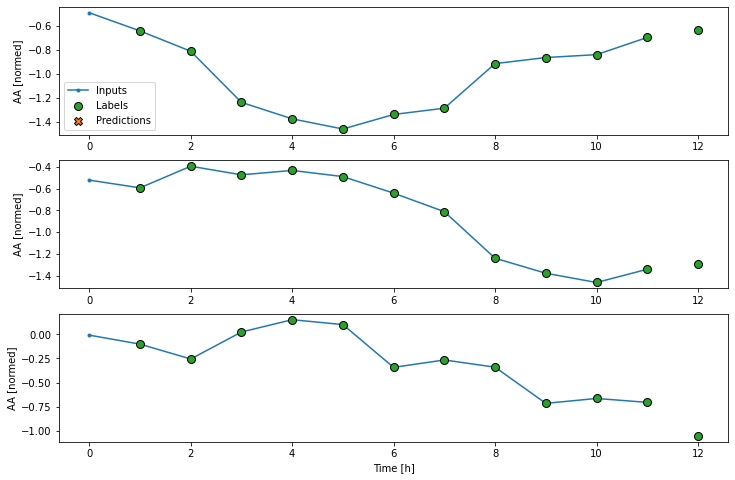

In [30]:

#Creamos una funcion para compilar nuestros modelos y predecir 
def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history, model

history, model = compile_and_fit(lstm_model, wide_window)

#Borra todo lo que se imprimio antes de este punto
IPython.display.clear_output()

#Evaluamos el desempeño de nuestro de nuestro modelo
#Usamos el error cuadratico medio y el error absoluto medio
val_performance = {}
performance = {}
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

#Graficamos los valores predecidos contra los reales 
wide_window.plot(lstm_model)

In [42]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# 1. Generate toy time series data
# ----------------------------
np.random.seed(42)
time = np.arange(100)
data = np.sin(time * 0.1) + np.random.normal(scale=0.1, size=len(time))

df = pd.DataFrame({"value": data})

# ----------------------------
# 2. Preprocess data
# ----------------------------
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["value"]])

# Create sequences (X: past 5 steps, y: next step)
window_size = 5
X, y = [], []
for i in range(len(scaled) - window_size):
    X.append(scaled[i:i+window_size])
    y.append(scaled[i+window_size])
X, y = np.array(X), np.array(y)

# ----------------------------
# 3. Build simple LSTM model
# ----------------------------
model = Sequential([
    LSTM(10, input_shape=(window_size, 1)),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=20, verbose=0)

# ----------------------------
# 4. Make predictions
# ----------------------------
preds = model.predict(X, verbose=0)
preds = scaler.inverse_transform(preds)

# Align predictions with original data
pred_series = pd.Series([None]*window_size + preds.flatten().tolist(), name="prediction")

# ----------------------------
# 5. Final DataFrame
# ----------------------------
result = pd.concat([df, pred_series], axis=1)

print(result.head(10))


      value  prediction
0  0.049671         NaN
1  0.086007         NaN
2  0.263438         NaN
3  0.447823         NaN
4  0.366003         NaN
5  0.456012   -0.284510
6  0.722564   -0.258871
7  0.720961   -0.224912
8  0.670409   -0.196210
9  0.837583   -0.179246
